In [64]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [49]:
df = pd.read_csv('/content/email_dataset_200.csv')

print("Columns:", df.columns)
df.head()

Columns: Index(['text', 'label'], dtype='object')


,text,label
0,Congratulations you won free prize,spam
1,Claim reward now,spam
2,Get free recharge today,spam
3,Win iphone now,spam
4,Urgent click here reward,spam


In [50]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

In [51]:
print(df.columns)

Index(['text', 'label'], dtype='object')


In [53]:
df['clean_text'] = df['text'].apply(clean_text)

X = df['clean_text']
y = df['label']
print('Data Ready:', X.shape, y.shape)

Data Ready: (200,) (200,)


In [54]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC(max_iter=2000),
    'Logistic Regression': LogisticRegression(max_iter=2000)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

    print(name, "Done")

Naive Bayes Done
SVM Done
Logistic Regression Done


In [57]:
results_df = pd.DataFrame(results, columns=['Model','Accuracy','Precision','Recall','F1'])
results_df

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,1.0,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0,1.0
2,Logistic Regression,1.0,1.0,1.0,1.0


In [58]:
best_model_name = results_df.sort_values('Accuracy', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Naive Bayes


In [59]:
import os
os.makedirs('/content/models', exist_ok=True)

joblib.dump(best_model, '/content/models/best_model.pkl')
joblib.dump(vectorizer, '/content/models/vectorizer.pkl')

print("Saved ✔")

Saved ✔


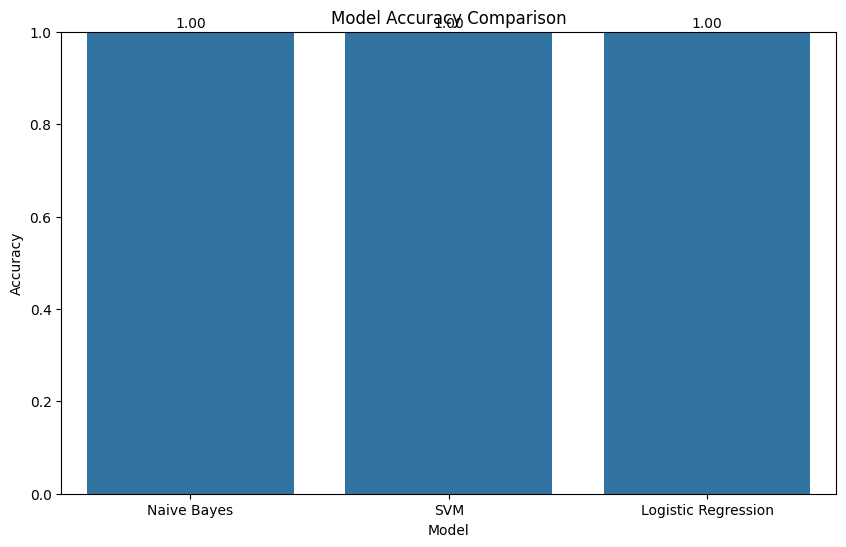

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(x="Model", y="Accuracy", data=results_df)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [62]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

1.0


In [65]:
params = {"C":[0.1,1,10]}

grid = GridSearchCV(LogisticRegression(), params, cv=5)
grid.fit(X_train,y_train)

print(grid.best_params_)

{'C': 0.1}


In [61]:
import joblib

model = joblib.load("/content/models/best_model.pkl")
vectorizer = joblib.load("/content/models/vectorizer.pkl")

text = input("Enter Message: ")

clean = clean_text(text)
vec = vectorizer.transform([clean])

prediction = model.predict(vec)[0]

print("Prediction:", prediction)

Enter Message: Congratulations you won free prize
Prediction: spam
